In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', None)
plt.rcParams['font.family'] = 'Microsoft JhengHei'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data.csv', sep = '\t')
print(df.head()) 
print(df.shape)
print(df.dtypes)

   race  age  engnat  gender  hand  source country  E1  E2  E3  ...  O1  O2  \
0     3   53       1       1     1       1      US   4   2   5  ...   4   1   
1    13   46       1       2     1       1      US   2   2   3  ...   3   3   
2     1   14       2       2     1       1      PK   5   1   1  ...   4   5   
3     3   19       2       2     1       1      RO   2   5   2  ...   4   3   
4    11   25       2       2     1       2      US   3   1   3  ...   3   1   

   O3  O4  O5  O6  O7  O8  O9  O10  
0   3   1   5   1   4   2   5    5  
1   3   3   2   3   3   1   3    2  
2   5   1   5   1   5   5   5    5  
3   5   2   4   2   5   2   5    5  
4   1   1   3   1   3   1   5    3  

[5 rows x 57 columns]
(19719, 57)
race        int64
age         int64
engnat      int64
gender      int64
hand        int64
source      int64
country    object
E1          int64
E2          int64
E3          int64
E4          int64
E5          int64
E6          int64
E7          int64
E8          int6

In [2]:
reverse_cols = ['E2','E4','E6','E8','E10','N2','N4','A1','A3','A5','A7','C2','C4','C6','C8','O2','O4','O6']
df[reverse_cols] = 6 - df[reverse_cols]
traits = ['E', 'N', 'A', 'C', 'O']
scores = pd.DataFrame()
for t in traits:
    scores[t + '_score'] = df.filter(regex=f"^{t}").mean(axis=1)


print(scores.head())


   E_score  N_score  A_score  C_score  O_score
0      4.4      1.1      4.6      4.7      4.3
1      2.2      3.1      3.5      4.2      2.6
2      3.5      4.6      3.8      4.9      4.5
3      2.2      4.3      3.7      2.6      4.1
4      3.4      3.0      4.4      3.4      3.4


In [3]:
df2 = pd.concat([df[['race','age','engnat','gender','hand','source','country']], scores], axis=1)
print(df2.shape)
print(df2.info())

(19719, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19719 entries, 0 to 19718
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   race     19719 non-null  int64  
 1   age      19719 non-null  int64  
 2   engnat   19719 non-null  int64  
 3   gender   19719 non-null  int64  
 4   hand     19719 non-null  int64  
 5   source   19719 non-null  int64  
 6   country  19710 non-null  object 
 7   E_score  19719 non-null  float64
 8   N_score  19719 non-null  float64
 9   A_score  19719 non-null  float64
 10  C_score  19719 non-null  float64
 11  O_score  19719 non-null  float64
dtypes: float64(5), int64(6), object(1)
memory usage: 1.8+ MB
None


In [4]:
df3 = df2[df2["age"] < 100]
print(df3['age'].describe())
print((df3['age'] > 150).sum())


count    19635.000000
mean        26.260046
std         11.555805
min         13.000000
25%         18.000000
50%         22.000000
75%         31.000000
max         99.000000
Name: age, dtype: float64
0


In [5]:
q75 = df3["O_score"].quantile(0.75)
q25 = df3["O_score"].quantile(0.25)

high_group = df3[df3["O_score"] > q75]
low_group = df3[df3["O_score"] < q25] 

print(q75, q25)
print(len(high_group), len(low_group))

4.4 3.5
4250 4466


In [6]:
import numpy as np

traits_to_compare = ['E', 'N', 'A', 'C']

for t in traits_to_compare:
    col = t + '_score'
    mean_diff = high_group[col].mean()-low_group[col].mean()
    pooled_std = np.sqrt((high_group[col].std()**2 + low_group[col].std()**2) / 2)
    cohens_d = mean_diff / pooled_std
    print(t, round(mean_diff,3), round(cohens_d,3))

E 0.408 0.44
N -0.22 -0.251
A 0.212 0.288
C 0.163 0.217


In [7]:
rows = []
for t in ['E', 'N', 'A', 'C']:
    col = t + '_score'
    rows.append({'trait': t, 'group': 'High O', 'mean_score': high_group[col].mean()})
    rows.append({'trait': t, 'group': 'Low O', 'mean_score': low_group[col].mean()})

plot_df = pd.DataFrame(rows)
print(plot_df)


  trait   group  mean_score
0     E  High O    3.191059
1     E   Low O    2.782893
2     N  High O    3.016894
3     N   Low O    3.236879
4     A  High O    3.923129
5     A   Low O    3.710860
6     C  High O    3.406494
7     C   Low O    3.243730


C:\Users\USER\AppData\Local\Temp\ipykernel_49528\2916351015.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['外向性', '神經質', '親和性', '嚴謹性'])


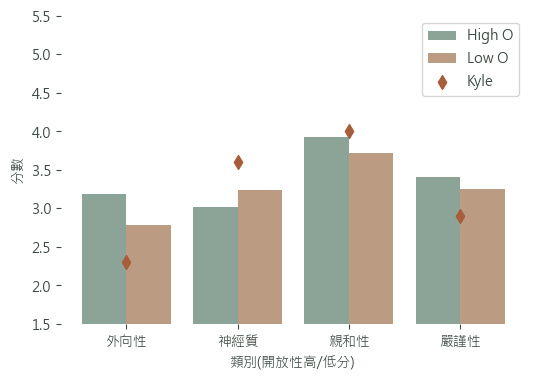

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor('none')
ax.set_facecolor('none')
sns.barplot(data=plot_df, x="trait", y="mean_score",
              hue="group", palette=["#88a898", "#c49a78"], errorbar="se", ax=ax)
plt.ylim(1.5,5.5)
# Kyle 分數
kyle_x = [0, 1, 2, 3]
kyle_y = [2.3, 3.6, 4.0, 2.9]
ax.scatter(kyle_x, kyle_y, color='#a85d3a', marker='d', s=50, zorder=5, label='Kyle')
# 文字顏色全部換成頁面的正文色
text_color = '#3d4a42'
ax.set_xlabel("類別(開放性高/低分)", color=text_color)
ax.set_ylabel("分數", color=text_color)
ax.tick_params(colors=text_color)

# 四邊邊框換成淡色，或直接拿掉
for spine in ax.spines.values():
    spine.set_color('none')
ax.legend(frameon=True, labelcolor='#3d4a42',facecolor='none',loc='upper right')
# 微調文字、邊框
ax.set_xticklabels(['外向性', '神經質', '親和性', '嚴謹性'])
plt.savefig('openness_comparison.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

In [9]:
trait_names = {'E': '外向性', 'N': '神經質', 'A': '親和性', 'C': '嚴謹性'}
trait_comparison = {}

for t in ['E', 'N', 'A', 'C']:
    col = t + '_score'
    high_mean = high_group[col].mean()
    low_mean = low_group[col].mean()
    mean_diff = high_group[col].mean()-low_group[col].mean()
    pooled_std = np.sqrt((high_group[col].std()**2 + low_group[col].std()**2) / 2)
    cohens_d = mean_diff / pooled_std
    
    trait_comparison[trait_names[t]] = {
        "高開放性平均": round(high_mean, 2),
        "低開放性平均": round(low_mean, 2),
        "差距": round(mean_diff, 3),
        "效果量": round(cohens_d, 3)
    }

print(trait_comparison)

{'外向性': {'高開放性平均': np.float64(3.19), '低開放性平均': np.float64(2.78), '差距': np.float64(0.408), '效果量': np.float64(0.44)}, '神經質': {'高開放性平均': np.float64(3.02), '低開放性平均': np.float64(3.24), '差距': np.float64(-0.22), '效果量': np.float64(-0.251)}, '親和性': {'高開放性平均': np.float64(3.92), '低開放性平均': np.float64(3.71), '差距': np.float64(0.212), '效果量': np.float64(0.288)}, '嚴謹性': {'高開放性平均': np.float64(3.41), '低開放性平均': np.float64(3.24), '差距': np.float64(0.163), '效果量': np.float64(0.217)}}


In [10]:
rows = []
for t in ['E', 'N', 'A', 'C']:
    col = t + '_score'
    rows.append({'trait': t, 'group': 'High O', 'mean_score': high_group[col].mean()})
    rows.append({'trait': t, 'group': 'Low O', 'mean_score': low_group[col].mean()})

plot_df = pd.DataFrame(rows)
print(plot_df)

  trait   group  mean_score
0     E  High O    3.191059
1     E   Low O    2.782893
2     N  High O    3.016894
3     N   Low O    3.236879
4     A  High O    3.923129
5     A   Low O    3.710860
6     C  High O    3.406494
7     C   Low O    3.243730


In [11]:
print(plot_df) 

  trait   group  mean_score
0     E  High O    3.191059
1     E   Low O    2.782893
2     N  High O    3.016894
3     N   Low O    3.236879
4     A  High O    3.923129
5     A   Low O    3.710860
6     C  High O    3.406494
7     C   Low O    3.243730


In [15]:
def get_percentile(score_column, value):
    return round((score_column <= value).mean() * 100, 1)
print(get_percentile(df3['E_score'], 2.3))    # 查 E 維度裡 2.3 分的百分位
print(get_percentile(df3['N_score'], 3.6))    # 查 N 維度裡 3.6 分的百分位
print(get_percentile(df3['O_score'], 4.4))    # 查 O 維度裡 4.4 分的百分位

25.5
71.6
78.4


In [ ]:
import numpy as np

traits = ['E', 'N', 'A', 'C', 'O']
percentile_table = {}

for t in traits:
    col = df3[t + '_score']
    trait_data = {}
    for score in np.arange(1.0, 5.1, 0.1):
        score = round(score, 1)
        trait_data[str(score)] = get_percentile(col,score)
    percentile_table[t] = trait_data

{'1.0': np.float64(0.9), '1.1': np.float64(1.6), '1.2': np.float64(2.5), '1.3': np.float64(3.5), '1.4': np.float64(4.9), '1.5': np.float64(6.3), '1.6': np.float64(7.9), '1.7': np.float64(9.7), '1.8': np.float64(12.0), '1.9': np.float64(14.1), '2.0': np.float64(16.7), '2.1': np.float64(19.4), '2.2': np.float64(22.4), '2.3': np.float64(25.5), '2.4': np.float64(28.9), '2.5': np.float64(32.5), '2.6': np.float64(36.3), '2.7': np.float64(39.7), '2.8': np.float64(43.6), '2.9': np.float64(47.3), '3.0': np.float64(51.4), '3.1': np.float64(55.3), '3.2': np.float64(59.0), '3.3': np.float64(62.7), '3.4': np.float64(66.4), '3.5': np.float64(69.9), '3.6': np.float64(73.1), '3.7': np.float64(76.3), '3.8': np.float64(79.4), '3.9': np.float64(82.3), '4.0': np.float64(85.0), '4.1': np.float64(87.5), '4.2': np.float64(90.0), '4.3': np.float64(92.1), '4.4': np.float64(93.9), '4.5': np.float64(95.5), '4.6': np.float64(96.9), '4.7': np.float64(97.8), '4.8': np.float64(98.8), '4.9': np.float64(99.4), '5.0': 

In [20]:
import json
with open(r"C:\Users\USER\Desktop\my-site\openness\percentile_lookup.json", "w", encoding="utf-8") as f:
    json.dump(percentile_table, f, ensure_ascii=False, indent=2)